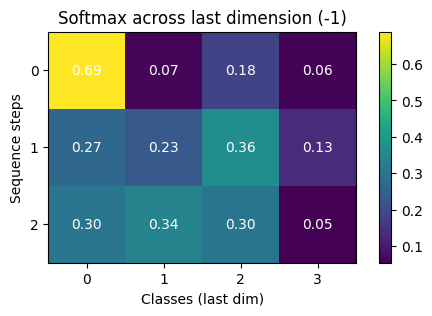

In [9]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Example tensor
X = torch.randn(2, 3, 4)  # (batch=2, seq=3, classes=4)
probs = F.softmax(X, dim=-1)  # normalize over last dimension

# Take batch 0 for visualization
batch0 = probs[0].detach().numpy()  # shape (3, 4) -> 3 timesteps × 4 classes

fig, ax = plt.subplots(figsize=(6, 3))
im = ax.imshow(batch0, cmap="viridis")

# Add text annotations for clarity
for i in range(batch0.shape[0]):
    for j in range(batch0.shape[1]):
        ax.text(j, i, f"{batch0[i, j]:.2f}", ha="center", va="center", color="w")

ax.set_xticks(range(batch0.shape[1]))
ax.set_yticks(range(batch0.shape[0]))
ax.set_xlabel("Classes (last dim)")
ax.set_ylabel("Sequence steps")
ax.set_title("Softmax across last dimension (-1)")
fig.colorbar(im, ax=ax)
plt.show()


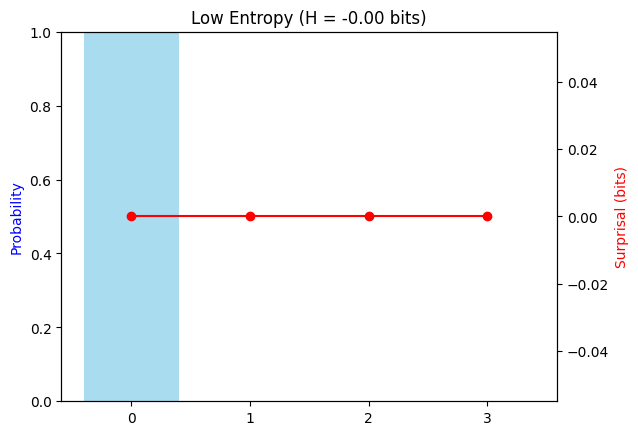

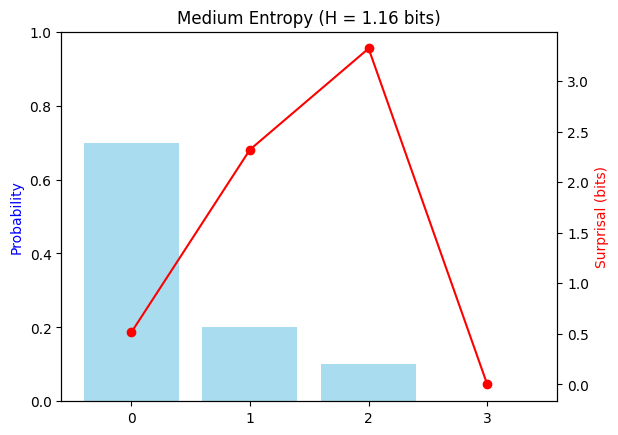

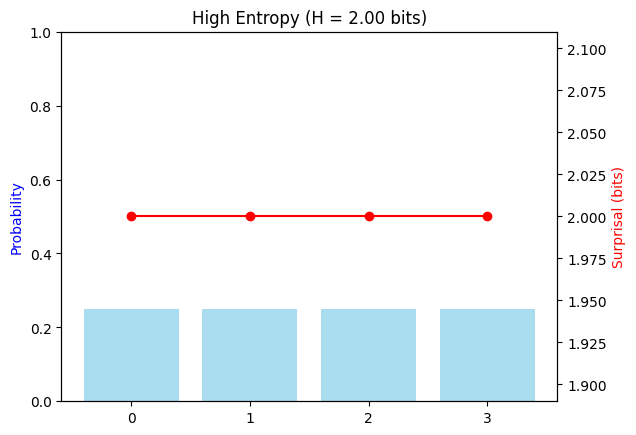

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Example probability distributions
p_low_entropy = [1.0, 0.0, 0.0, 0.0]     # always one symbol
p_medium_entropy = [0.7, 0.2, 0.1, 0.0]  # somewhat predictable
p_high_entropy = [0.25, 0.25, 0.25, 0.25] # uniform distribution

def entropy(p):
    p = np.array(p)
    p = p[p > 0]  # ignore zeros to avoid log issues
    return -np.sum(p * np.log2(p))

# Compute entropies
H_low = entropy(p_low_entropy)
H_medium = entropy(p_medium_entropy)
H_high = entropy(p_high_entropy)

# Plotting function
def plot_distribution(p, title):
    events = np.arange(len(p))
    surprisal = [-np.log2(pi) if pi > 0 else 0 for pi in p]
    
    fig, ax1 = plt.subplots()
    
    # Bar chart for probabilities
    ax1.bar(events, p, color="skyblue", alpha=0.7, label="Probability")
    ax1.set_ylabel("Probability", color="blue")
    ax1.set_ylim(0, 1)
    ax1.set_xticks(events)
    ax1.set_title(title)
    
    # Line plot for surprisal
    ax2 = ax1.twinx()
    ax2.plot(events, surprisal, "ro-", label="Surprisal (-log2 p)")
    ax2.set_ylabel("Surprisal (bits)", color="red")
    
    plt.show()

# Visualize all three cases
plot_distribution(p_low_entropy, f"Low Entropy (H = {H_low:.2f} bits)")
plot_distribution(p_medium_entropy, f"Medium Entropy (H = {H_medium:.2f} bits)")
plot_distribution(p_high_entropy, f"High Entropy (H = {H_high:.2f} bits)")


In [11]:
%matplotlib inline
import time
import torch
import torchvision
from torchvision import transforms
from d2l import torch as d2l

d2l.use_svg_display()

In [12]:
class FashionMNIST(d2l.DataModule):  #@save
    """The Fashion-MNIST dataset."""
    def __init__(self, batch_size=64, resize=(28, 28)):
        super().__init__()
        self.save_hyperparameters()
        trans = transforms.Compose([transforms.Resize(resize),
                                    transforms.ToTensor()])
        self.train = torchvision.datasets.FashionMNIST(
            root=self.root, train=True, transform=trans, download=True)
        self.val = torchvision.datasets.FashionMNIST(
            root=self.root, train=False, transform=trans, download=True)

In [13]:
data = FashionMNIST(resize=(32, 32))
len(data.train), len(data.val)

100%|███████████████████████████████████████████████████████████| 26.4M/26.4M [00:34<00:00, 764kB/s]
100%|███████████████████████████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 107kB/s]
100%|██████████████████████████████████████████████████████████| 4.42M/4.42M [00:03<00:00, 1.27MB/s]
100%|██████████████████████████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 5.51MB/s]


(60000, 10000)

In [19]:
data.train[0][0].shape

torch.Size([1, 32, 32])

In [20]:
@d2l.add_to_class(FashionMNIST)  #@save
def text_labels(self, indices):
    """Return text labels."""
    labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
              'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [labels[int(i)] for i in indices]

In [21]:
@d2l.add_to_class(FashionMNIST)  #@save
def get_dataloader(self, train):
    data = self.train if train else self.val
    return torch.utils.data.DataLoader(data, self.batch_size, shuffle=train,
                                       num_workers=self.num_workers)

In [22]:
X, y = next(iter(data.train_dataloader()))
print(X.shape, X.dtype, y.shape, y.dtype)

torch.Size([64, 1, 32, 32]) torch.float32 torch.Size([64]) torch.int64


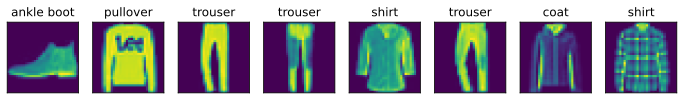

In [23]:
@d2l.add_to_class(FashionMNIST)  #@save
def visualize(self, batch, nrows=1, ncols=8, labels=[]):
    X, y = batch
    if not labels:
        labels = self.text_labels(y)
    d2l.show_images(X.squeeze(1), nrows, ncols, titles=labels)
batch = next(iter(data.val_dataloader()))
data.visualize(batch)

In [27]:
class Classifier(d2l.Module):  #@save
    """The base class of classification models."""
    def validation_step(self, batch):
        Y_hat = self(*batch[:-1])
        self.plot('loss', self.loss(Y_hat, batch[-1]), train=False)
        self.plot('acc', self.accuracy(Y_hat, batch[-1]), train=False)

In [28]:
@d2l.add_to_class(d2l.Module)  #@save
def configure_optimizers(self):
    return torch.optim.SGD(self.parameters(), lr=self.lr)

In [32]:
a = torch.rand(2, 3, 4)

In [36]:
a.reshape(-1, a.shape[-1]).shape

torch.Size([6, 4])

In [38]:
Y_hat = torch.tensor([[0.1, 0.9], [0.8, 0.2], [0.3, 0.7]])
Y = torch.tensor([1, 0, 1])

In [41]:
Y_hat = Y_hat.reshape((-1, Y_hat.shape[-1]))
Y_hat.argmax(axis=1)

tensor([1, 0, 1])

In [42]:
@d2l.add_to_class(Classifier)  #@save
def accuracy(self, Y_hat, Y, averaged=True):
    """Compute the number of correct predictions."""
    Y_hat = Y_hat.reshape((-1, Y_hat.shape[-1]))
    preds = Y_hat.argmax(axis=1).type(Y.dtype)
    compare = (preds == Y.reshape(-1)).type(torch.float32)
    return compare.mean() if averaged else compare

In [43]:
X = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
X

tensor([[1., 2., 3.],
        [4., 5., 6.]])

In [44]:
X.sum(0, keepdims=True), X.sum(1, keepdims=True)

(tensor([[5., 7., 9.]]),
 tensor([[ 6.],
         [15.]]))

In [45]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdims=True)
    return X_exp / partition  # The broadcasting mechanism is applied here

In [46]:
X = torch.rand((2, 5))
X_prob = softmax(X)
X_prob, X_prob.sum(1)

(tensor([[0.1764, 0.2387, 0.1564, 0.1766, 0.2519],
         [0.2405, 0.2494, 0.2306, 0.1101, 0.1694]]),
 tensor([1.0000, 1.0000]))

In [ ]:
class SoftmaxRegressionScratch(d2l.Classifier):
    def __init__(self, num_inputs, num_outputs, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.W = torch.normal(0, sigma, size=(num_inputs, num_outputs),
                              requires_grad=True)
        self.b = torch.zeros(num_outputs, requires_grad=True)

    def parameters(self):
        return [self.W, self.b]